# Solving CartPole-v1 with PPO (from scratch)

This notebook demonstrates how to solve the CartPole-v1 environment using a custom implementation of the Proximal Policy Optimization (PPO) algorithm in PyTorch. No external RL libraries are used.

---

**Note:** All environment and hyperparameter settings are now collected in a single `CONFIG` dictionary at the top of the notebook. To change the environment or any hyperparameter, simply edit the values in the config cell.

## 1. Install and Import Required Libraries
We will use gymnasium and torch for this implementation.

In [1]:
%pip install stable-baselines3 gymnasium tsilva-notebook-utils==0.0.104 --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
from tsilva_notebook_utils.colab import load_secrets_into_env

_ = load_secrets_into_env([
    'WANDB_API_KEY',
    'NOTIFICATION_URL',
    'NOTIFICATION_AUTH_TOKEN'
])

In [3]:
from wandb import login
login()

wandb: Currently logged in as: tsilva to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## 2. Set Up CartPole-v1 Environment
We will initialize the CartPole-v1 environment and display its basic information.

In [4]:
ENV_ID = "CartPole-v1"
#ENV_ID = "Acrobot-v1"
#ENV_ID = "LunarLander-v3"
#ENV_ID = "Pendulum-v1"
#ENV_ID = "MountainCar-v0"

In [5]:
import torch
import torch.nn as nn
import numpy as np
from tsilva_notebook_utils.gymnasium import build_env as _build_env, set_random_seed

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# --- Config dictionary for all hyperparameters and environment settings ---
def setup_config(env_id):
    common = dict(
        env_id=env_id,         # Environment name
        seed=42,               # Random seed for reproducibility
        gamma=0.99,            # Discount factor for future rewards
        lam=0.95,              # GAE lambda for advantage estimation
        clip_epsilon=0.2,      # PPO clip range for policy update
        minibatch_size=64,     # Minibatch size for SGD
        episodes_per_epoch=20, # Number of episodes per training epoch
        eval_interval=5,       # Evaluate every N epochs
        eval_episodes=20,      # Number of episodes for evaluation
        reward_threshold=200,  # Reward threshold to consider environment solved
        policy_lr=3e-4,        # Learning rate for policy network
        value_lr=1e-3,         # Learning rate for value network
        hidden_dim=64,         # Hidden layer size for networks
        entropy_coef=0.01,     # Coefficient for entropy bonus (encourages exploration)
        normalize=False,       # Whether to use input normalization
        n_envs="auto"          # Maximum number of parallel environments
    )
    env_specific = {
        "CartPole-v1": dict(
            gamma=0.99,           # Standard discount for CartPole
            lam=0.95,             # GAE lambda, balances bias/variance
            clip_epsilon=0.2,     # PPO clip range, stable for CartPole
            minibatch_size=32,    # Smaller batch for faster updates
            episodes_per_epoch=16,# Fewer episodes per epoch for quick feedback
            eval_interval=2,      # Evaluate more frequently for fast convergence
            eval_episodes=10,     # Fewer eval episodes for speed
            reward_threshold=475, # Official CartPole-v1 solved threshold
            policy_lr=3e-4,       # Standard PPO learning rate
            value_lr=1e-3,        # Slightly higher for value net
            hidden_dim=64,        # Small net is sufficient for CartPole
            entropy_coef=0.01     # Typical entropy for CartPole
        ),
        "LunarLander-v3": dict(
            gamma=0.99,           # Standard discount for LunarLander
            lam=0.95,             # GAE lambda, balances bias/variance
            clip_epsilon=0.2,     # PPO clip range, stable for LunarLander
            minibatch_size=64,    # Larger batch for more stable updates
            episodes_per_epoch=8, # Fewer episodes per epoch (env is longer)
            eval_interval=2,      # Evaluate every 2 epochs
            eval_episodes=5,      # Fewer eval episodes for speed
            reward_threshold=200, # Solved threshold for LunarLander-v3
            policy_lr=1e-4,       # Lower LR for more complex env
            value_lr=5e-4,        # Lower LR for value net
            hidden_dim=128,       # Larger net for more complex env
            entropy_coef=0.02     # Higher entropy for more exploration
        ),
        "Acrobot-v1": dict(
            gamma=0.99,           # Standard discount for Acrobot
            lam=0.95,             # GAE lambda, balances bias/variance
            clip_epsilon=0.2,     # PPO clip range, stable for Acrobot
            minibatch_size=32,    # Smaller batch for faster updates
            episodes_per_epoch=16,# Fewer episodes per epoch for quick feedback
            eval_interval=2,      # Evaluate more frequently for fast convergence
            eval_episodes=10,     # Fewer eval episodes for speed
            reward_threshold=-100, # Solved threshold for Acrobot-v1 (average reward > -100)
            policy_lr=3e-4,       # Standard PPO learning rate
            value_lr=1e-3,        # Slightly higher for value net
            hidden_dim=64,        # Small net is sufficient for Acrobot
            entropy_coef=0.01     # Typical entropy for Acrobot
        ),
        "Pendulum-v1": dict(
            gamma=0.99,           # Standard discount for Pendulum
            lam=0.95,             # GAE lambda, balances bias/variance
            clip_epsilon=0.2,     # PPO clip range, stable for Pendulum
            minibatch_size=64,    # Larger batch for continuous action
            episodes_per_epoch=8, # Fewer episodes per epoch (env is longer)
            eval_interval=2,      # Evaluate every 2 epochs
            eval_episodes=5,      # Fewer eval episodes for speed
            reward_threshold=-200, # Solved threshold for Pendulum-v1 (average reward > -200)
            policy_lr=3e-4,       # Standard PPO learning rate
            value_lr=1e-3,        # Slightly higher for value net
            hidden_dim=128,       # Larger net for continuous control
            entropy_coef=0.0      # No entropy for deterministic continuous control
        ),
        "MountainCar-v0": dict(
            gamma=0.99,             # Discount factor (keep)
            lam=0.97,               # Slightly higher GAE lambda for more bias reduction
            clip_epsilon=0.15,      # Tighter PPO clip for more stable updates
            minibatch_size=16,      # Smaller minibatch for more frequent updates
            episodes_per_epoch=24,  # More episodes per epoch for better sampling
            eval_interval=2,        # Keep frequent evaluation
            eval_episodes=10,       # Keep
            reward_threshold=-110,  # Keep
            policy_lr=1e-4,         # Lower learning rate for more stable policy updates
            value_lr=5e-4,          # Lower value net LR for stability
            hidden_dim=128,         # Larger network for more capacity
            entropy_coef=0.05       # Higher entropy for hard exploration
        ),
    }
    if env_id not in env_specific:
        raise ValueError(f"Unsupported env_id: {env_id}")
    return {**common, **env_specific[env_id]}

CONFIG = setup_config(ENV_ID)
CONFIG

Using device: cuda


{'env_id': 'CartPole-v1',
 'seed': 42,
 'gamma': 0.99,
 'lam': 0.95,
 'clip_epsilon': 0.2,
 'minibatch_size': 32,
 'episodes_per_epoch': 16,
 'eval_interval': 2,
 'eval_episodes': 10,
 'reward_threshold': 475,
 'policy_lr': 0.0003,
 'value_lr': 0.001,
 'hidden_dim': 64,
 'entropy_coef': 0.01,
 'normalize': False,
 'n_envs': 'auto'}

In [6]:
# Set random seed for reproducibility
set_random_seed(CONFIG['seed'])

# Wrap build env with config parameters
build_env = lambda seed: _build_env(
    CONFIG['env_id'], 
    norm_obs=CONFIG['normalize'], 
    n_envs=CONFIG['n_envs'], seed=seed
)

# Test building env
env = build_env(CONFIG['seed'])
obs_dim = env.observation_space.shape[0]
act_dim = env.action_space.n
print(f"Observation space: {env.observation_space}")
print(f"Action space: {env.action_space}")

Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)


## 3. Implement PPO Agent
We will define the policy and value networks, and the PPO update step.

In [7]:
class PolicyNet(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden_dim=None):
        super().__init__()
        h = hidden_dim or CONFIG['hidden_dim']
        self.net = nn.Sequential(
            nn.Linear(obs_dim, h), nn.Tanh(),
            nn.Linear(h, h), nn.Tanh(),
            nn.Linear(h, act_dim)
        )
    def forward(self, x):
        return self.net(x)

class ValueNet(nn.Module):
    def __init__(self, obs_dim, hidden_dim=None):
        super().__init__()
        h = hidden_dim or CONFIG['hidden_dim']
        self.net = nn.Sequential(
            nn.Linear(obs_dim, h), nn.Tanh(),
            nn.Linear(h, h), nn.Tanh(),
            nn.Linear(h, 1)
        )
    def forward(self, x):
        return self.net(x)

## 4. Train PPO Agent
We will train the PPO agent on CartPole-v1.

In [8]:
import random
import torch.optim as optim
import time  # <-- Ensure time is imported for wall time
from torch.distributions import Categorical
from tsilva_notebook_utils.gymnasium import collect_rollouts

# Set fixed seed for training
env = build_env(CONFIG['seed'])
obs = env.reset()

# PPO Training Loop
entropy_coef = CONFIG.get('entropy_coef', 0.0)
device = 'cuda'
policy_model = PolicyNet(obs_dim, act_dim, hidden_dim=CONFIG['hidden_dim']).to(device)
value_model = ValueNet(obs_dim, hidden_dim=CONFIG['hidden_dim']).to(device)
policy_optim = optim.Adam(policy_model.parameters(), lr=CONFIG['policy_lr'])
value_optim = optim.Adam(value_model.parameters(), lr=CONFIG['value_lr'])

clip_epsilon = CONFIG['clip_epsilon']
minibatch_size = CONFIG['minibatch_size']
gamma = CONFIG['gamma']
lam = CONFIG['lam']
episodes_per_epoch = CONFIG['episodes_per_epoch']
eval_interval = CONFIG['eval_interval']
eval_episodes = CONFIG['eval_episodes']
reward_threshold = CONFIG['reward_threshold']

train_rewards = []  # Store mean reward per epoch
solved = False
current_epoch = 0

start_time = time.time()  # <-- Start wall time measurement

while not solved:
    # Use collect_rollouts for training
    episode_rewards, (obs_buf, act_buf, rew_buf, done_buf, logp_buf, val_buf, adv_buf) = collect_rollouts(env,
        policy_model, value_model=value_model, n_episodes=episodes_per_epoch, deterministic=False)
    train_rewards.append(np.mean(episode_rewards))
    
    # TODO: try moving this to collect_rollouts
    # Truncate val_buf to match adv_buf length (in case of partial episodes)
    val_buf_trunc = val_buf[:len(adv_buf)]
    ret_buf = (np.array(adv_buf) + np.array(val_buf_trunc)).tolist()
    # Convert buffers to tensors and move to device
    obs_t = torch.as_tensor(np.array(obs_buf[:len(adv_buf)]), dtype=torch.float32, device=device)
    act_tensor = torch.as_tensor(np.array(act_buf[:len(adv_buf)]), dtype=torch.int64, device=device)
    adv_tensor = torch.as_tensor(np.array(adv_buf), dtype=torch.float32, device=device)
    ret_tensor = torch.as_tensor(np.array(ret_buf), dtype=torch.float32, device=device)
    logp_old_tensor = torch.as_tensor(np.array(logp_buf[:len(adv_buf)]), dtype=torch.float32, device=device)
    # Normalize advantages
    adv_tensor = (adv_tensor - adv_tensor.mean()) / (adv_tensor.std() + 1e-8)

    # PPO update
    num_samples = len(obs_t)
    for _ in range(10): # TODO: gradient steps?
        idx = np.random.permutation(num_samples)
        for start in range(0, num_samples, minibatch_size):
            end = min(start + minibatch_size, num_samples)
            mb_idx = idx[start:end]
            policy_logits = policy_model(obs_t[mb_idx])
            logits_dist = Categorical(logits=policy_logits)
            logp = logits_dist.log_prob(act_tensor[mb_idx])
            ratio = torch.exp(logp - logp_old_tensor[mb_idx])
            surr1 = ratio * adv_tensor[mb_idx]
            surr2 = torch.clamp(ratio, 1 - clip_epsilon, 1 + clip_epsilon) * adv_tensor[mb_idx]
            entropy = logits_dist.entropy().mean()
            policy_loss = -torch.min(surr1, surr2).mean() - entropy_coef * entropy
            value_pred = value_model(obs_t[mb_idx]).squeeze()
            value_loss = ((ret_tensor[mb_idx] - value_pred) ** 2).mean()
            policy_optim.zero_grad()
            policy_loss.backward()
            policy_optim.step()
            value_optim.zero_grad()
            value_loss.backward()
            value_optim.step()
    current_epoch += 1
    print(f"Epoch {current_epoch} complete. Mean train reward: {train_rewards[-1]:.2f}")
    if current_epoch % eval_interval == 0:
        ep_rewards, trajectories = collect_rollouts(
            build_env(random.randint(0, 1_000_000)),
            policy_model,
            n_episodes=eval_episodes,
            deterministic=False
        )
        mean_eval_reward = np.mean(ep_rewards)
        print(f"Evaluation after {current_epoch} epochs: Mean reward = {mean_eval_reward:.2f}")
        if mean_eval_reward >= reward_threshold:
            print(f"Solved! Mean evaluation reward {mean_eval_reward:.2f} >= {reward_threshold}")
            solved = True

end_time = time.time()  # <-- End wall time measurement
print(f"Total training wall time: {end_time - start_time:.2f} seconds")

Epoch 1 complete. Mean train reward: 16.19
Epoch 2 complete. Mean train reward: 16.62
Evaluation after 2 epochs: Mean reward = 16.10


KeyboardInterrupt: 

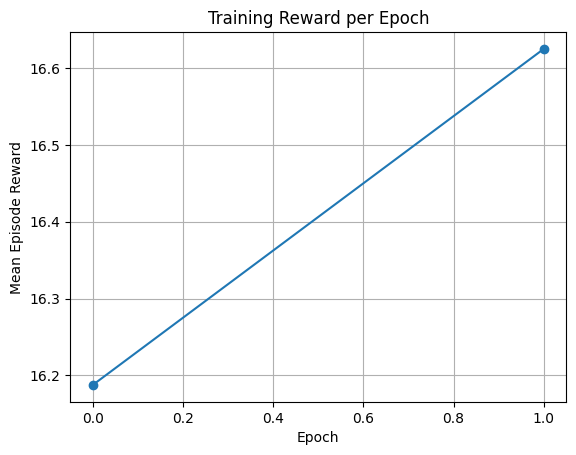

In [9]:
# Plot training rewards after training
import matplotlib.pyplot as plt
plt.plot(train_rewards, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Mean Episode Reward')
plt.title('Training Reward per Epoch')
plt.grid(True)
plt.show()

In [10]:
from tsilva_notebook_utils.gymnasium import render_episode_frames

import random

ep_rewards, trajectories, frames = collect_rollouts(
    build_env(random.randint(0, 1_000_000)),
    policy_model,
    n_episodes=4,
    deterministic=True,
    collect_frames=True
)
mean_reward = float(np.mean(ep_rewards))
print(f"Mean reward: {mean_reward:.2f}")
render_episode_frames(frames, out_dir="./tmp", grid=(2, 2), text_color=(0, 0, 0))

Mean reward: 41.25


- TODO: Consider using RolloutBuffer
- TODO: Adapt for Torch Lightning